In [2]:
# Import Libraries ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:

df = pd.read_csv('../data/online_retail_II.csv', encoding='latin-1')

print(f"✅ Data loaded successfully")
print(f"📦 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\n🔍 First 3 rows:")
df.head(3)

✅ Data loaded successfully
📦 Shape: 1,067,371 rows × 8 columns

📋 Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

🔍 First 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [4]:
print("=" * 50)
print("📊 BASIC INFO")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("❓ MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 50)
print("🔢 BASIC STATISTICS")
print("=" * 50)
print(df[['Quantity', 'Price']].describe())

📊 BASIC INFO
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB
None

❓ MISSING VALUES
             Missing Count  Missing %
Description           4382       0.41
Customer ID         243007      22.77

🔢 BASIC STATISTICS
           Quantity         Price
count  1.067371e+06  1.067371e+06
mean   9.938898e+00  4.649388e+00
std    1.727058e+02  1.235531e+02
min   -8.099500e+04 -5.359436e+04
25%    1.000000e+00  1.250000e+00
50%    3.000000e+00  2.100

In [5]:
# Data Cleaning 

print("Shape before cleaning:", df.shape)

# ── Step 1: Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"✅ After removing cancellations: {df.shape[0]:,} rows")

# ── Step 2: Remove negative or zero quantities
df = df[df['Quantity'] > 0]
print(f"✅ After removing negative/zero quantity: {df.shape[0]:,} rows")

# ── Step 3: Remove negative or zero prices
df = df[df['Price'] > 0]
print(f"✅ After removing negative/zero prices: {df.shape[0]:,} rows")

# ── Step 4: Remove rows with missing Description
df = df.dropna(subset=['Description'])
print(f"✅ After removing missing descriptions: {df.shape[0]:,} rows")

# ── Step 5: Fill missing Customer ID with 'Guest'
df['Customer ID'] = df['Customer ID'].fillna('Guest')
print(f"✅ Missing Customer IDs filled with 'Guest'")

# ── Step 6: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"✅ InvoiceDate converted to datetime")

# ── Step 7: Create Revenue column (Quantity × Price)
df['Revenue'] = df['Quantity'] * df['Price']
print(f"✅ Revenue column created")

# ── Step 8: Extract date parts for analysis
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek'] = df['InvoiceDate'].dt.strftime('%a')
df['Hour'] = df['InvoiceDate'].dt.hour
print(f"✅ Date columns extracted")

print("\n" + "="*50)
print(f"🎯 FINAL CLEAN SHAPE: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("="*50)

# Quick sanity check
print(f"\n📊 Sanity Check:")
print(f"   Min Quantity: {df['Quantity'].min()}")
print(f"   Min Price: {df['Price'].min()}")
print(f"   Missing Customer IDs: {df['Customer ID'].isnull().sum()}")
print(f"   Total Revenue: £{df['Revenue'].sum():,.2f}")

Shape before cleaning: (1067371, 8)
✅ After removing cancellations: 1,047,877 rows
✅ After removing negative/zero quantity: 1,044,420 rows
✅ After removing negative/zero prices: 1,041,670 rows
✅ After removing missing descriptions: 1,041,670 rows
✅ Missing Customer IDs filled with 'Guest'
✅ InvoiceDate converted to datetime
✅ Revenue column created
✅ Date columns extracted

🎯 FINAL CLEAN SHAPE: 1,041,670 rows × 14 columns

📊 Sanity Check:
   Min Quantity: 1
   Min Price: 0.001
   Missing Customer IDs: 0
   Total Revenue: £20,972,594.57


In [ ]:
# Business Questions Overview 

print("🔍 5 BUSINESS QUESTIONS TO ANSWER:")
print()
print("  Q1. How has revenue trended over time?")
print("      → Monthly revenue chart")
print()
print("  Q2. Which are the top 10 best-selling products?")
print("      → Bar chart by revenue")
print()
print("  Q3. Which countries generate the most revenue?")
print("      → Bar chart by country")
print()
print("  Q4. What days and hours do customers shop most?")
print("      → Heatmap of transactions")
print()
print("  Q5. Who are the top customers by spend?")
print("      → Bar chart of top 10 customers")
print()
print("="*50)
print(f"📦 Working dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"💰 Total Revenue: £{df['Revenue'].sum():,.2f}")# the colon and comma after shows the result should  have comma separators
print(f"🛒 Unique Invoices: {df['Invoice'].nunique():,}")
print(f"🏷️  Unique Products: {df['Description'].nunique():,}")
print(f"🌍 Countries: {df['Country'].nunique():,}")
print(f"👥 Unique Customers: {df['Customer ID'].nunique():,}")

🔍 5 BUSINESS QUESTIONS TO ANSWER:

  Q1. How has revenue trended over time?
      → Monthly revenue chart

  Q2. Which are the top 10 best-selling products?
      → Bar chart by revenue

  Q3. Which countries generate the most revenue?
      → Bar chart by country

  Q4. What days and hours do customers shop most?
      → Heatmap of transactions

  Q5. Who are the top customers by spend?
      → Bar chart of top 10 customers

📦 Working dataset: 1,041,670 rows × 14 columns
💰 Total Revenue: £20,972,594.57
🛒 Unique Invoices: 40,077
🏷️  Unique Products: 5,399
🌍 Countries: 43
👥 Unique Customers: 5,879


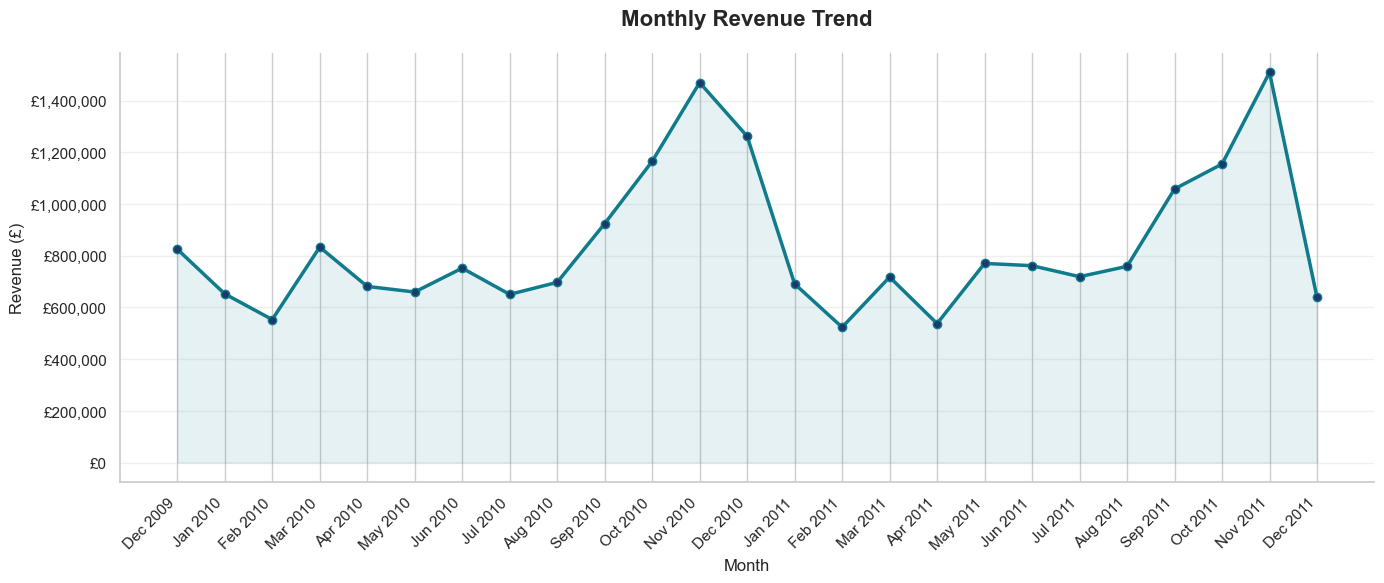

✅ Chart saved to visuals folder

📊 Revenue Summary:
   Best month:  Nov 2011 — £1,509,496.33
   Worst month: Feb 2011 — £523,631.89


In [7]:
#  Q1 — Monthly Revenue Trend

# Group by Year and Month
monthly_revenue = (
    df.groupby(['Year', 'Month', 'MonthName'])['Revenue']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Month'])
)

# Create a readable label e.g. "Jan 2010"
monthly_revenue['Period'] = (
    monthly_revenue['MonthName'] + ' ' + 
    monthly_revenue['Year'].astype(str)
)

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_revenue['Period'],
    monthly_revenue['Revenue'],
    color='#0F7B8C',
    linewidth=2.5,
    marker='o',
    markersize=6,
    markerfacecolor='#1B3A6B'
)

# Shade under the line
ax.fill_between(
    range(len(monthly_revenue)),
    monthly_revenue['Revenue'],
    alpha=0.1,
    color='#0F7B8C'
)

# Formatting
ax.set_title('Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue (£)', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
plt.xticks(
    range(len(monthly_revenue)),
    monthly_revenue['Period'],
    rotation=45,
    ha='right'
)
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/q1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to visuals folder")

# Summary numbers
print(f"\n📊 Revenue Summary:")
print(f"   Best month:  {monthly_revenue.loc[monthly_revenue['Revenue'].idxmax(), 'Period']} — £{monthly_revenue['Revenue'].max():,.2f}")
print(f"   Worst month: {monthly_revenue.loc[monthly_revenue['Revenue'].idxmin(), 'Period']} — £{monthly_revenue['Revenue'].min():,.2f}")

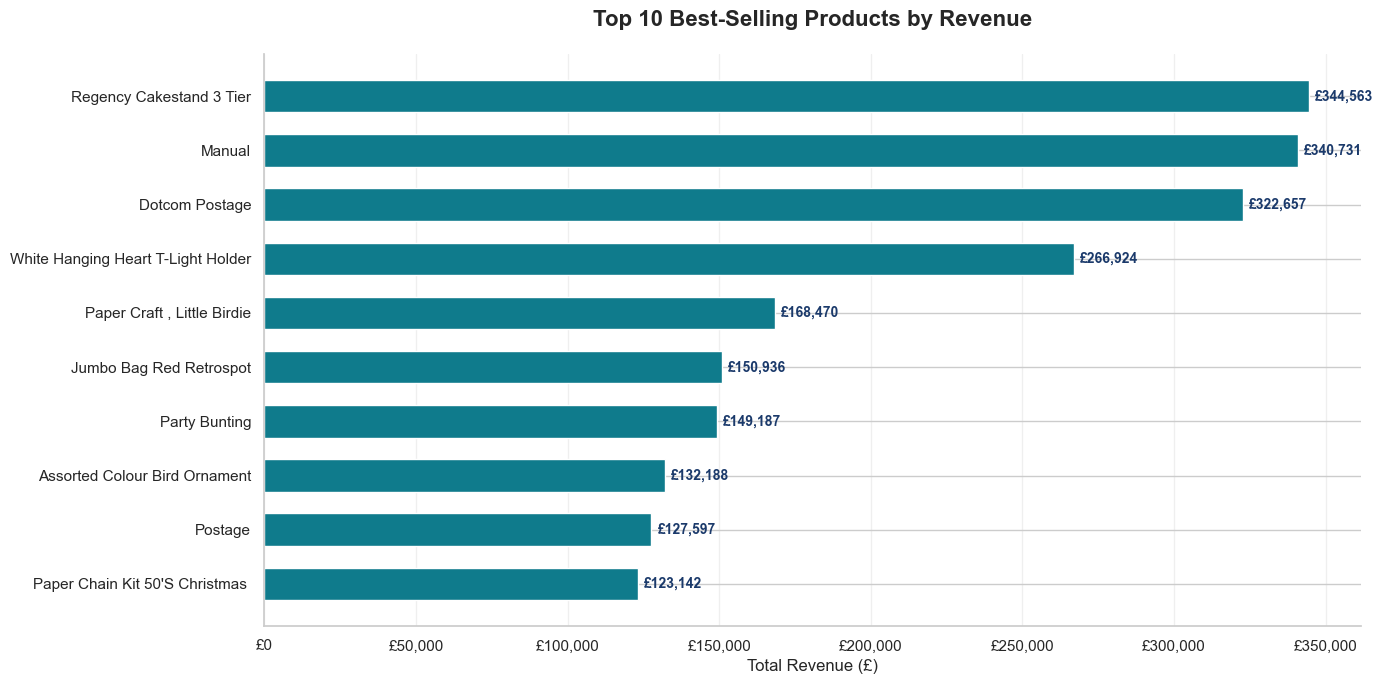

✅ Chart saved to visuals folder

🏆 Top 10 Products:
   Regency Cakestand 3 Tier: £344,563.25
   Manual: £340,731.33
   Dotcom Postage: £322,657.48
   White Hanging Heart T-Light Holder: £266,923.55
   Paper Craft , Little Birdie: £168,469.60
   Jumbo Bag Red Retrospot: £150,935.56
   Party Bunting: £149,187.05
   Assorted Colour Bird Ornament: £132,187.92
   Postage: £127,597.42
   Paper Chain Kit 50'S Christmas : £123,141.54


In [10]:
# Q2 — Top 10 Products by Revenue 

top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)

# Shorten long names for display
top_products['Short Name'] = top_products['Description'].str.title().str[:40]

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    top_products['Short Name'][::-1],
    top_products['Revenue'][::-1],
    color='#0F7B8C',
    edgecolor='white',
    height=0.6
)

# Add value labels on bars
for bar, val in zip(bars, top_products['Revenue'][::-1]):
    ax.text(
        bar.get_width() + 2000,
        bar.get_y() + bar.get_height() / 2,
        f'£{val:,.0f}',
        va='center',
        fontsize=10,
        color='#1B3A6B',
        fontweight='bold'
    )

# Formatting
ax.set_title('Top 10 Best-Selling Products by Revenue',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax.grid(axis='x', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/q2_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to visuals folder")
print("\n🏆 Top 10 Products:")
for i, row in top_products.head(10).iterrows():
    print(f"   {row['Description'].title()[:45]}: £{row['Revenue']:,.2f}")

In [11]:
#  Remove Non-Product Entries ───────────────────

# These are not real products - expanded list
non_products = [
    'MANUAL', 
    'DOTCOM POSTAGE', 
    'POSTAGE',
    'CRUK COMMISSION', 
    'BANK CHARGES',
    'AMAZON FEE',
    'EBAY FEE'
]

df = df[~df['Description'].str.upper().isin(non_products)]

print(f"✅ Non-product entries removed")
print(f"📦 Updated shape: {df.shape[0]:,} rows")

# Recheck top 10 to make sure all clean
top_products_clean = (
    df.groupby('Description')['Revenue']
    .sum()
    .reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)

print(f"\n🏆 Top 10 Real Products After Cleaning:")
for i, (_, row) in enumerate(top_products_clean.iterrows(), 1):
    print(f"   {i}. {row['Description'].title()[:45]}: £{row['Revenue']:,.2f}")

✅ Non-product entries removed
📦 Updated shape: 1,037,430 rows

🏆 Top 10 Real Products After Cleaning:
   1. Regency Cakestand 3 Tier: £344,563.25
   2. White Hanging Heart T-Light Holder: £266,923.55
   3. Paper Craft , Little Birdie: £168,469.60
   4. Jumbo Bag Red Retrospot: £150,935.56
   5. Party Bunting: £149,187.05
   6. Assorted Colour Bird Ornament: £132,187.92
   7. Paper Chain Kit 50'S Christmas : £123,141.54
   8. Chilli Lights: £85,489.91
   9. Medium Ceramic Top Storage Jar: £81,700.92
   10. Rotating Silver Angels T-Light Hldr: £74,448.92


In [12]:
# ── Investigate suspicious entries ───────────────────────
suspicious = ['MANUAL', 'DOTCOM POSTAGE', 'POSTAGE']

check = df[df['Description'].str.upper().isin(suspicious)][
    ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']
].drop_duplicates('Description')

print(check)

Empty DataFrame
Columns: [Invoice, StockCode, Description, Quantity, Price]
Index: []


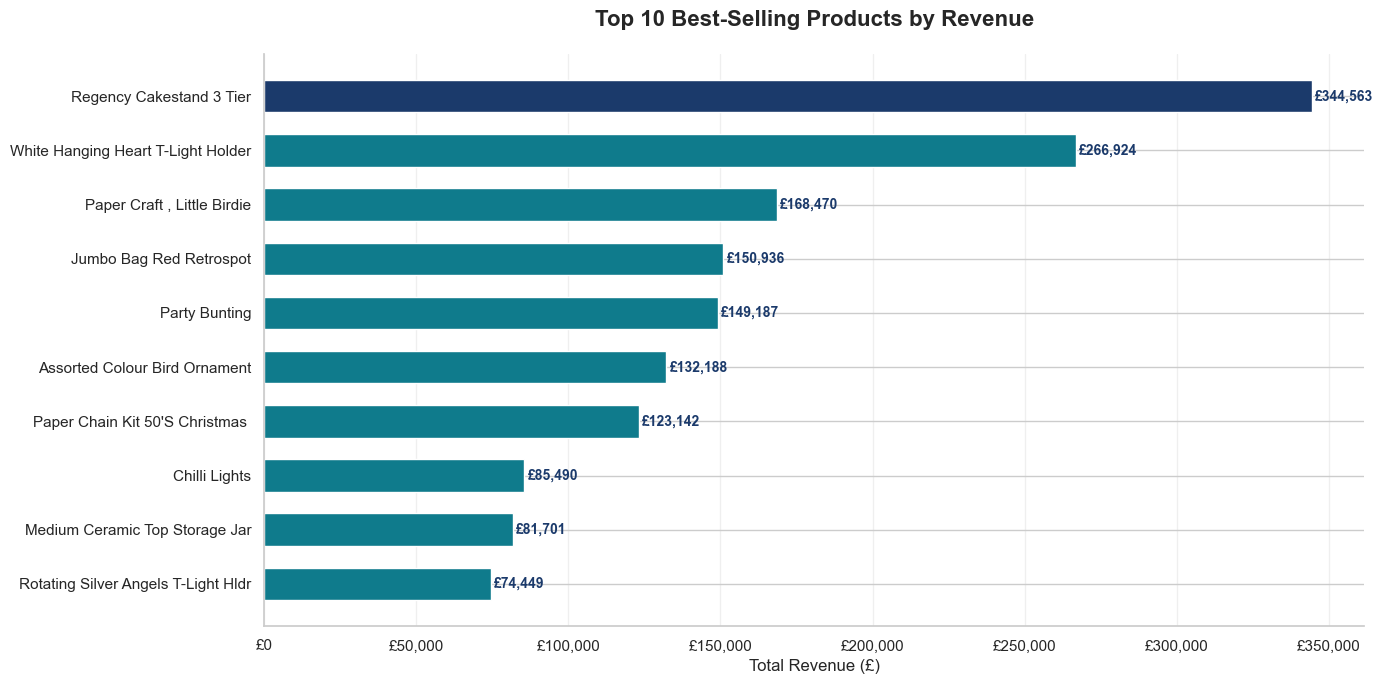

✅ Q2 chart saved cleanly


In [16]:
# Q2 Chart Regenerated — Clean Top 10 

top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .reset_index()
    .sort_values('Revenue', ascending=False)
    .head(10)
)

top_products['Short Name'] = top_products['Description'].str.title().str[:35]

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#1B3A6B' if i == 0 else '#0F7B8C' 
          for i in range(len(top_products))]

bars = ax.barh(
    top_products['Short Name'][::-1],
    top_products['Revenue'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, top_products['Revenue'][::-1]):
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f'£{val:,.0f}',
        va='center',
        fontsize=10,
        color='#1B3A6B',
        fontweight='bold'
    )

ax.set_title('Top 10 Best-Selling Products by Revenue',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax.grid(axis='x', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/q2_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Q2 chart saved cleanly")

In [17]:
# Q3 — Revenue by Country

# Group by country - exclude UK as it dominates everything
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .reset_index()
    .sort_values('Revenue', ascending=False)
)

# Separate UK from the rest
uk_revenue = country_revenue[country_revenue['Country'] == 'United Kingdom']['Revenue'].values[0]
other_countries = country_revenue[country_revenue['Country'] != 'United Kingdom'].head(10)

print(f"🇬🇧 UK Revenue: £{uk_revenue:,.2f}")
print(f"📊 UK share of total: {uk_revenue/df['Revenue'].sum()*100:.1f}%")
print(f"\n🌍 Top 10 Non-UK Countries:")
for i, (_, row) in enumerate(other_countries.iterrows(), 1):
    print(f"   {i}. {row['Country']}: £{row['Revenue']:,.2f}")

🇬🇧 UK Revenue: £17,257,777.72
📊 UK share of total: 85.7%

🌍 Top 10 Non-UK Countries:
   1. EIRE: £640,557.00
   2. Netherlands: £549,952.66
   3. Germany: £388,959.99
   4. France: £317,401.53
   5. Australia: £168,484.66
   6. Spain: £98,840.54
   7. Switzerland: £94,270.29
   8. Sweden: £86,353.04
   9. Denmark: £68,560.19
   10. Belgium: £57,322.77


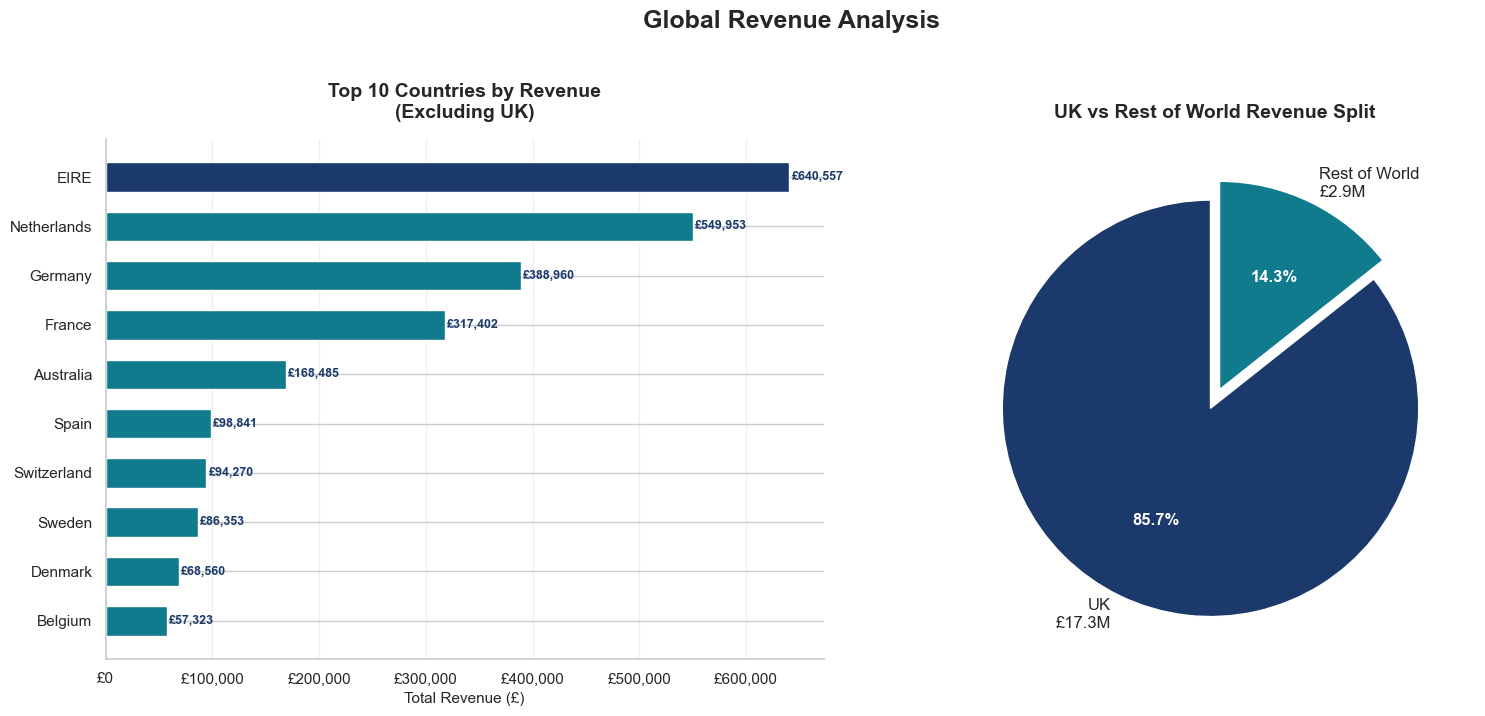

✅ Q3 chart saved

💡 Key Insight: UK generates 85.7% of revenue.
   International markets represent a £2,889,317 opportunity
   with Ireland, Netherlands and Germany leading growth.


In [18]:
# Q3 Chart — Top 10 Countries ex-UK 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── Left chart: Bar chart of top 10 non-UK countries ─────
colors = ['#1B3A6B' if i == 0 else '#0F7B8C' 
          for i in range(len(other_countries))]

bars = ax1.barh(
    other_countries['Country'][::-1],
    other_countries['Revenue'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, other_countries['Revenue'][::-1]):
    ax1.text(
        bar.get_width() + 2000,
        bar.get_y() + bar.get_height() / 2,
        f'£{val:,.0f}',
        va='center',
        fontsize=9,
        color='#1B3A6B',
        fontweight='bold'
    )

ax1.set_title('Top 10 Countries by Revenue\n(Excluding UK)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Total Revenue (£)', fontsize=11)
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax1.grid(axis='x', alpha=0.3)
sns.despine(ax=ax1)

# ── Right chart: Pie chart UK vs Rest of World ────────────
rest_of_world = df[df['Country'] != 'United Kingdom']['Revenue'].sum()

sizes = [uk_revenue, rest_of_world]
labels = [f'UK\n£{uk_revenue/1e6:.1f}M', 
          f'Rest of World\n£{rest_of_world/1e6:.1f}M']
colors_pie = ['#1B3A6B', '#0F7B8C']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax2.pie(
    sizes,
    labels=labels,
    colors=colors_pie,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_title('UK vs Rest of World Revenue Split',
              fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Global Revenue Analysis', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../visuals/q3_country_revenue.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Q3 chart saved")
print(f"\n💡 Key Insight: UK generates 85.7% of revenue.")
print(f"   International markets represent a £{rest_of_world:,.0f} opportunity")
print(f"   with Ireland, Netherlands and Germany leading growth.")

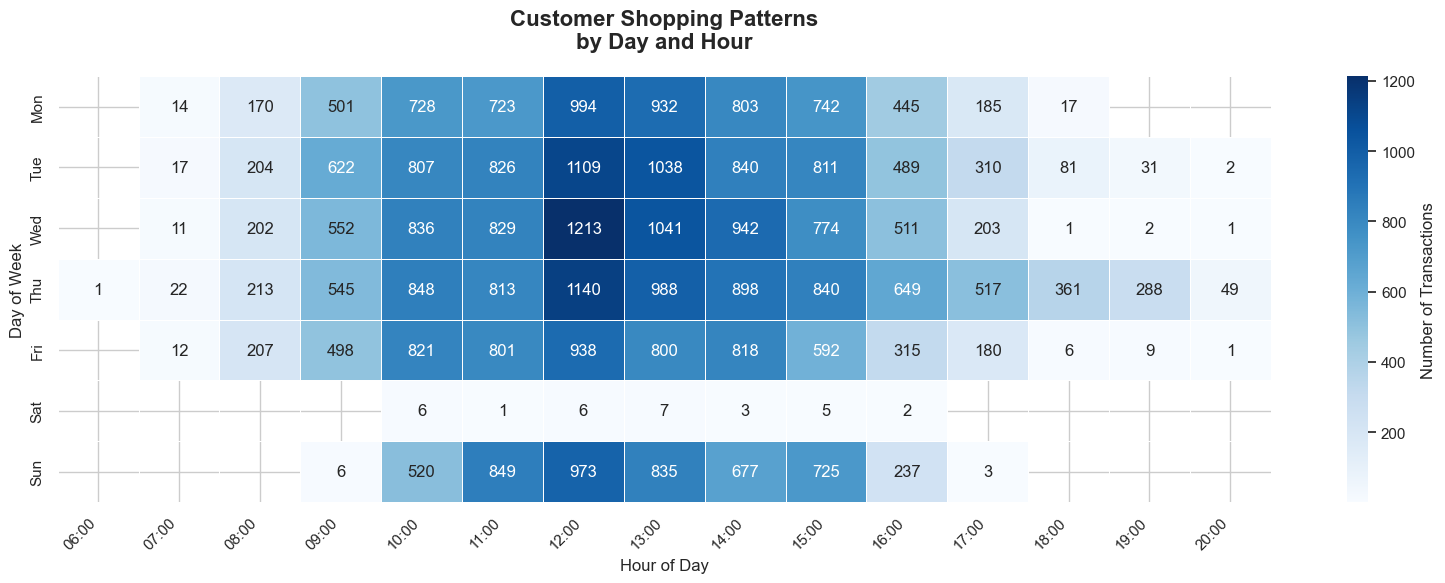

✅ Q4 heatmap saved

💡 Busiest time: Wed at 12:00
   Transactions: 1,213

💡 Sunday insight: 4825 total Sunday transactions


In [ ]:
# Q4 — Shopping Patterns Heatmap 

# Order days and hours properly
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
hour_order = list(range(6, 21))  # 6am to 8pm

# Group by day and hour
heatmap_data = (
    df.groupby(['DayOfWeek', 'Hour'])['Invoice']
    .nunique()
    .reset_index()
    .rename(columns={'Invoice': 'Transactions'})
)

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(
    index='DayOfWeek',
    columns='Hour',
    values='Transactions'
).reindex(day_order)

# Keep only business hours
heatmap_pivot = heatmap_pivot[
    [col for col in hour_order if col in heatmap_pivot.columns]
]

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    heatmap_pivot,
    cmap='Blues',
    annot=True,
    fmt='g',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Number of Transactions'}
)

ax.set_title('Customer Shopping Patterns\nby Day and Hour',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_xticklabels(
    [f'{h:02d}:00' for h in hour_order],
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.savefig('../visuals/q4_shopping_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Q4 heatmap saved")

# Key insight
busiest = heatmap_data.loc[heatmap_data['Transactions'].idxmax()]
print(f"\n💡 Busiest time: {busiest['DayOfWeek']} at {int(busiest['Hour']):02d}:00")
print(f"   Transactions: {int(busiest['Transactions']):,}")
print(f"\n💡 Sunday insight: {heatmap_data[heatmap_data['DayOfWeek']=='Sun']['Transactions'].sum()} total Sunday transactions")

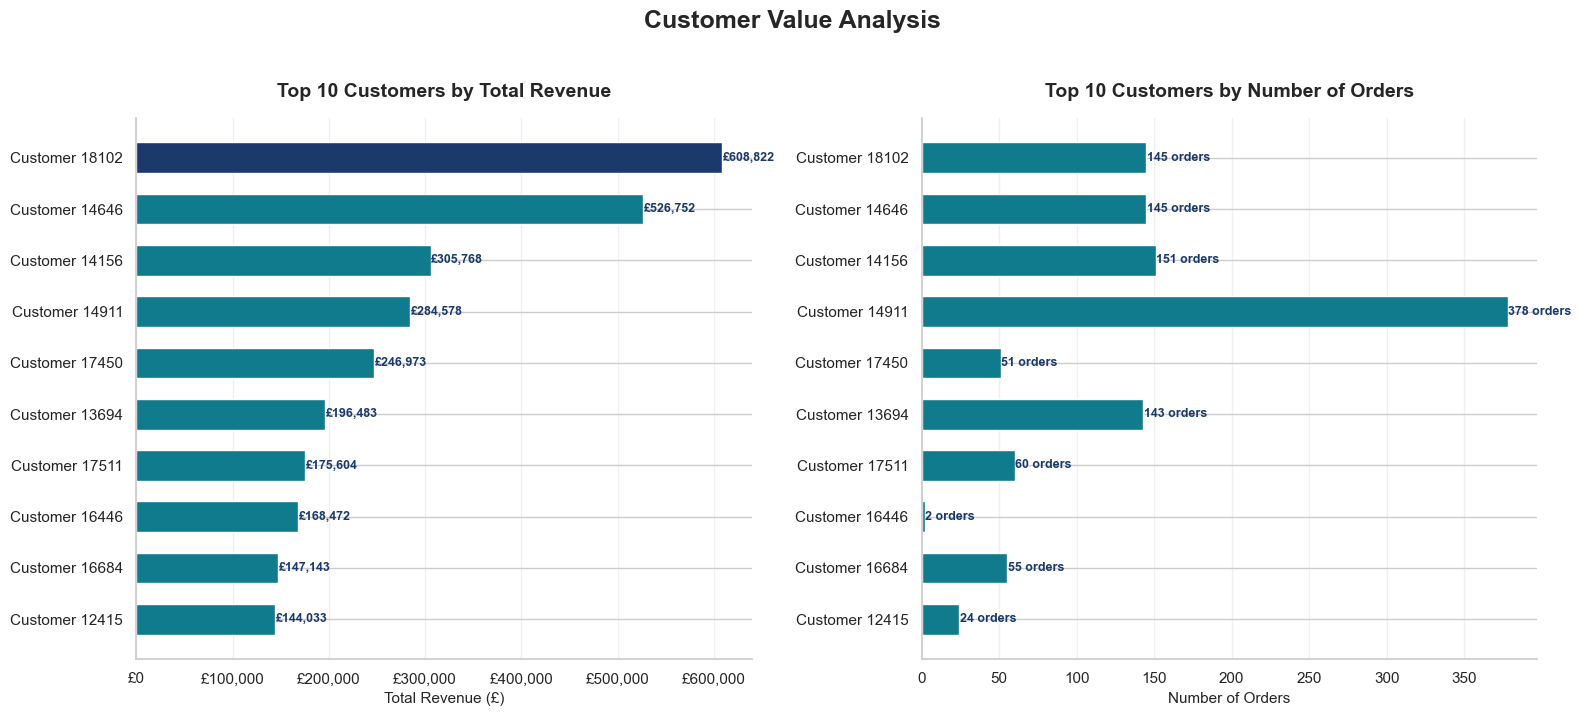

✅ Q5 chart saved

💡 Top Customer Summary:
Customer                  Revenue   Orders  Avg Order £
-------------------------------------------------------
Customer 18102       £   608,822      145 £     4,199
Customer 14646       £   526,752      145 £     3,633
Customer 14156       £   305,768      151 £     2,025
Customer 14911       £   284,578      378 £       753
Customer 17450       £   246,973       51 £     4,843
Customer 13694       £   196,483      143 £     1,374
Customer 17511       £   175,604       60 £     2,927
Customer 16446       £   168,472        2 £    84,236
Customer 16684       £   147,143       55 £     2,675
Customer 12415       £   144,033       24 £     6,001


In [20]:
# Q5 — Top 10 Customers by Spend 

# Exclude guests since they have no ID
top_customers = (
    df[df['Customer ID'] != 'Guest']
    .groupby('Customer ID')
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Total_Orders=('Invoice', 'nunique'),
        Total_Items=('Quantity', 'sum'),
        Avg_Order_Value=('Revenue', lambda x: x.sum() / df.loc[x.index, 'Invoice'].nunique())
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
    .head(10)
)

top_customers['Customer ID'] = 'Customer ' + top_customers['Customer ID'].astype(str).str.split('.').str[0]

# ── Plot ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Total Revenue per customer ─────────────────────
colors = ['#1B3A6B' if i == 0 else '#0F7B8C'
          for i in range(len(top_customers))]

bars = ax1.barh(
    top_customers['Customer ID'][::-1],
    top_customers['Total_Revenue'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, top_customers['Total_Revenue'][::-1]):
    ax1.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'£{val:,.0f}',
        va='center',
        fontsize=9,
        color='#1B3A6B',
        fontweight='bold'
    )

ax1.set_title('Top 10 Customers by Total Revenue',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Total Revenue (£)', fontsize=11)
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax1.grid(axis='x', alpha=0.3)
sns.despine(ax=ax1)

# ── Right: Number of orders per customer ─────────────────
bars2 = ax2.barh(
    top_customers['Customer ID'][::-1],
    top_customers['Total_Orders'][::-1],
    color='#0F7B8C',
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars2, top_customers['Total_Orders'][::-1]):
    ax2.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,} orders',
        va='center',
        fontsize=9,
        color='#1B3A6B',
        fontweight='bold'
    )

ax2.set_title('Top 10 Customers by Number of Orders',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Number of Orders', fontsize=11)
ax2.grid(axis='x', alpha=0.3)
sns.despine(ax=ax2)

plt.suptitle('Customer Value Analysis',
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../visuals/q5_top_customers.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Q5 chart saved")
print(f"\n💡 Top Customer Summary:")
print(f"{'Customer':<20} {'Revenue':>12} {'Orders':>8} {'Avg Order £':>12}")
print("-" * 55)
for _, row in top_customers.iterrows():
    print(f"{row['Customer ID']:<20} £{row['Total_Revenue']:>10,.0f} {row['Total_Orders']:>8} £{row['Avg_Order_Value']:>10,.0f}")

In [22]:
# ── Fix Customer ID format ────────────────────────────────
df['Customer ID'] = df['Customer ID'].apply(
    lambda x: str(int(float(x))) if x != 'Guest' else 'Guest'
)

print("✅ Customer ID fixed")
print("Sample values:", df['Customer ID'].head(10).tolist())
print("Data type:", df['Customer ID'].dtype)

✅ Customer ID fixed
Sample values: ['13085', '13085', '13085', '13085', '13085', '13085', '13085', '13085', '13085', '13085']
Data type: str


In [24]:
# Investigate Customers 18102 vs 14646 

for customer in ['18102', '14646']:
    cust_data = df[df['Customer ID'] == customer]
    
    print(f"{'='*50}")
    print(f"👤 Customer {customer}")
    print(f"{'='*50}")
    print(f"   Total Revenue:    £{cust_data['Revenue'].sum():,.2f}")
    print(f"   Total Orders:     {cust_data['Invoice'].nunique():,}")
    print(f"   Total Items:      {cust_data['Quantity'].sum():,}")
    print(f"   Avg Order Value:  £{cust_data.groupby('Invoice')['Revenue'].sum().mean():,.2f}")
    print(f"   Avg Item Price:   £{cust_data['Price'].mean():,.2f}")
    print(f"   Countries:        {cust_data['Country'].unique()}")
    print(f"\n   🏆 Top 3 Products:")
    top3 = (cust_data.groupby('Description')['Revenue']
            .sum().sort_values(ascending=False).head(3))
    for prod, rev in top3.items():
        print(f"      {prod.title()[:40]}: £{rev:,.2f}")
    print()

👤 Customer 18102
   Total Revenue:    £608,821.65
   Total Orders:     145
   Total Items:      188,340
   Avg Order Value:  £4,198.77
   Avg Item Price:   £3.90
   Countries:        <StringArray>
['United Kingdom']
Length: 1, dtype: str

   🏆 Top 3 Products:
      Vintage Union Jack Memoboard: £32,975.92
      Wood Black Board Ant White Finish: £28,301.28
      Cream Heart Card Holder: £26,897.42

👤 Customer 14646
   Total Revenue:    £526,751.52
   Total Orders:     145
   Total Items:      367,072
   Avg Order Value:  £3,632.77
   Avg Item Price:   £2.35
   Countries:        <StringArray>
['Netherlands']
Length: 1, dtype: str

   🏆 Top 3 Products:
      Round Snack Boxes Set Of4 Woodland : £13,102.70
      Dolly Girl Lunch Box: £10,563.90
      White Hanging Heart T-Light Holder: £10,532.30




Customer 14646 actually buys TWICE as many items — 367,072 vs 188,340. But they spend less overall because their average item price is only £2.35 vs £3.90.

This reveals two completely different buyer profiles:

Customer 18102 — Premium UK Buyer
Buys fewer items but chooses higher-value products like memo boards and decorative pieces. Likely a boutique gift shop curating a quality collection.

Customer 14646 — Volume Netherlands Buyer
Buys enormous quantities of cheaper items — lunch boxes, hanging hearts. Likely a large distributor or discount retailer buying in bulk to resell cheaply.

This is a real business insight:
"Top customers by revenue are not always top customers by volume. Segmenting customers by average item price reveals two distinct wholesale buyer personas — premium curators vs volume distributors — each requiring a different sales and retention strategy."*


In [26]:
#  Fix CSV for Power BI ─────────────────────────

# Check what's causing the mixed type issue
print("Sample Customer IDs:")
print(df['Customer ID'].head(10).tolist())

# Ensure all columns have clean types
df['Customer ID'] = df['Customer ID'].astype(str)
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Hour'] = df['Hour'].astype(int)
df['Quantity'] = df['Quantity'].astype(int)
df['Revenue'] = df['Revenue'].round(2)
df['Price'] = df['Price'].round(2)

# Re-export cleanly
df.to_csv('../data/online_retail_clean.csv', index=False, encoding='utf-8')

print("✅ Clean CSV re-exported with fixed data types")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

Sample Customer IDs:
['13085', '13085', '13085', '13085', '13085', '13085', '13085', '13085', '13085', '13085']
✅ Clean CSV re-exported with fixed data types
   Rows: 1,037,430
   Columns: 14
